# `prescriptive_analysis.py`

Phase 4 — Prescriptive: 4 đề xuất định lượng (floor price = cogs, win-back RFM segment, nhân rộng pricing West). Notebook chạy đúng code gốc (chia theo 3 đề xuất, khớp print header `"="*70` trong script), chart hiện inline.

In [1]:
%matplotlib inline
import os
os.chdir(r"/Users/lhoanghai_/Downloads/Dự án datathon2026")
__file__ = r"/Users/lhoanghai_/Downloads/Dự án datathon2026/EDA_Insight/phase4_prescriptive/prescriptive_analysis.py"  # notebook không có __file__ mặc định -> gán thủ công để mọi Path(__file__)... trong code gốc resolve đúng thư mục như khi chạy .py


## Thiết lập / import

In [2]:
# Phase 4 — Prescriptive: 4 đề xuất định lượng
# Đọc: data/{order_items,orders,products}.csv (raw, chỉ đọc)
#      + phase2_diagnostic/data/category_region_margin_controlled.csv
#      + phase3_dashboard/data/{rfm_customer_segments,churn_risk_scores}.csv
# Xuất: phase4_prescriptive/data/*.csv + output/phase4/36..38_*.png
# Chạy: .venv/bin/python EDA_Insight/phase4_prescriptive/prescriptive_analysis.py

import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use("Agg")  # bỏ trong notebook để %matplotlib inline hiển thị chart
import matplotlib.pyplot as plt
from pathlib import Path

HERE = Path(__file__).resolve().parent                  # EDA_Insight/phase4_prescriptive/
ROOT = HERE.parent.parent                                # project root
DATA = ROOT / "data"                                      # raw data (chỉ đọc)
P2 = HERE.parent / "phase2_diagnostic" / "data"
P3 = HERE.parent / "phase3_dashboard" / "data"
OUT_DATA = HERE / "data"
OUT_CHART = HERE.parent / "output" / "phase4"
OUT_DATA.mkdir(parents=True, exist_ok=True)
OUT_CHART.mkdir(parents=True, exist_ok=True)

PALETTE = ["#185FA5", "#A32D2D", "#3B6D11", "#BA7517", "#534AB7", "#993556"]
plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linestyle": ":"})

## ĐỀ XUẤT 1 — Floor price cho promotion (`unit_price_floor = max(unit_price, cogs)`)

ĐỀ XUẤT 1 — FLOOR PRICE CHO PROMOTION


/var/folders/t9/tstf90y13wd9p_7gc7pf9htr0000gp/T/ipykernel_73381/1639486450.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  items = pd.read_csv(DATA / "order_items.csv")


Tổng số dòng order_items (toàn bộ lịch sử): 714,669
Số dòng bán dưới giá vốn: 133,052 (18.62%)

Revenue thực tế (gross, toàn lịch sử): 16.430 tỷ VND
COGS thực tế: 14.163 tỷ VND
Gross margin thực tế: 13.80% (2.267 tỷ VND)

Nếu áp floor price = cogs (loại bỏ hoàn toàn bán dưới giá vốn):
Revenue giả định: 16.892 tỷ VND (+0.462 tỷ)
Gross margin giả định: 16.15% (2.729 tỷ VND)
=> Margin tăng thêm: +2.36 điểm % , +0.462 tỷ VND

Theo category (tỷ VND margin tăng thêm):
  category  margin_gain_vnd  margin_gain_pp
Streetwear            0.409        2.619425
   Outdoor            0.041        1.353585
    Casual            0.008        1.547211
      GenZ            0.003        0.807984


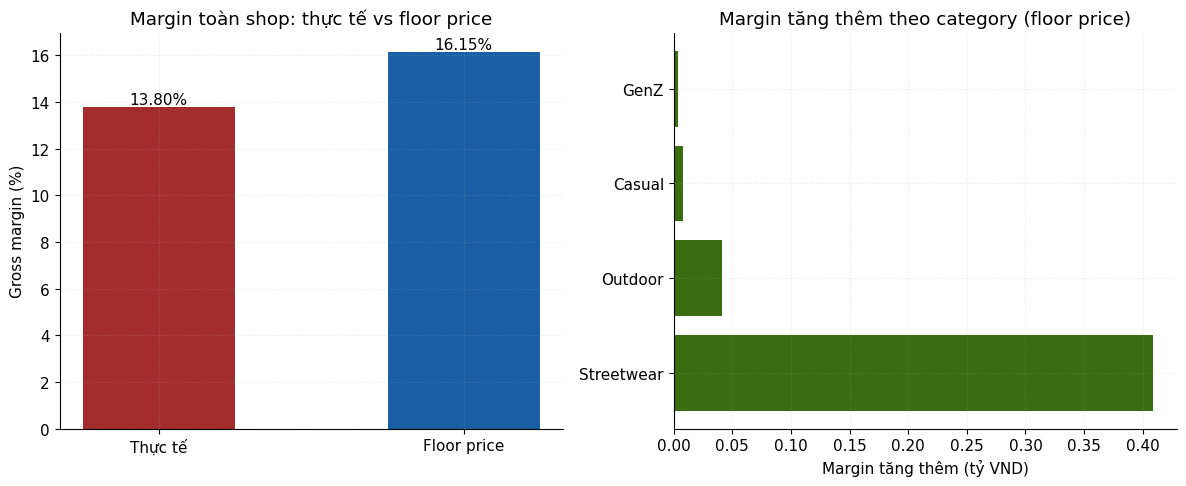

In [3]:
print("=" * 70)
print("ĐỀ XUẤT 1 — FLOOR PRICE CHO PROMOTION")
print("=" * 70)

items = pd.read_csv(DATA / "order_items.csv")
orders = pd.read_csv(DATA / "orders.csv", parse_dates=["order_date"], usecols=["order_id", "order_date", "zip"])
products = pd.read_csv(DATA / "products.csv", usecols=["product_id", "category", "cogs", "price"])

li = (items.merge(orders, on="order_id", how="left")
           .merge(products, on="product_id", how="left"))

li["line_revenue"] = li["quantity"] * li["unit_price"]
li["line_cogs"] = li["quantity"] * li["cogs"]
# Floor price = max(unit_price, cogs) — không bán dưới giá vốn ở bất kỳ dòng nào
li["unit_price_floor"] = np.maximum(li["unit_price"], li["cogs"])
li["line_revenue_floor"] = li["quantity"] * li["unit_price_floor"]

n_total = len(li)
n_below = (li["unit_price"] < li["cogs"]).sum()
print(f"Tổng số dòng order_items (toàn bộ lịch sử): {n_total:,}")
print(f"Số dòng bán dưới giá vốn: {n_below:,} ({n_below/n_total*100:.2f}%)")

rev_actual = li["line_revenue"].sum()
cogs_actual = li["line_cogs"].sum()
margin_actual_pct = (1 - cogs_actual / rev_actual) * 100
margin_actual_vnd = rev_actual - cogs_actual

rev_floor = li["line_revenue_floor"].sum()
cogs_floor = cogs_actual  # COGS catalog không đổi, chỉ giá bán đổi
margin_floor_pct = (1 - cogs_floor / rev_floor) * 100
margin_floor_vnd = rev_floor - cogs_floor

margin_gain_vnd = margin_floor_vnd - margin_actual_vnd
margin_gain_pp = margin_floor_pct - margin_actual_pct

print(f"\nRevenue thực tế (gross, toàn lịch sử): {rev_actual/1e9:.3f} tỷ VND")
print(f"COGS thực tế: {cogs_actual/1e9:.3f} tỷ VND")
print(f"Gross margin thực tế: {margin_actual_pct:.2f}% ({margin_actual_vnd/1e9:.3f} tỷ VND)")
print(f"\nNếu áp floor price = cogs (loại bỏ hoàn toàn bán dưới giá vốn):")
print(f"Revenue giả định: {rev_floor/1e9:.3f} tỷ VND (+{(rev_floor-rev_actual)/1e9:.3f} tỷ)")
print(f"Gross margin giả định: {margin_floor_pct:.2f}% ({margin_floor_vnd/1e9:.3f} tỷ VND)")
print(f"=> Margin tăng thêm: +{margin_gain_pp:.2f} điểm % , +{margin_gain_vnd/1e9:.3f} tỷ VND")

# Theo category
cat_g = li.groupby("category").agg(
    revenue=("line_revenue", "sum"),
    cogs=("line_cogs", "sum"),
    revenue_floor=("line_revenue_floor", "sum"),
).reset_index()
cat_g["margin_pct_actual"] = (1 - cat_g["cogs"] / cat_g["revenue"]) * 100
cat_g["margin_pct_floor"] = (1 - cat_g["cogs"] / cat_g["revenue_floor"]) * 100
cat_g["margin_gain_vnd"] = (cat_g["revenue_floor"] - cat_g["cogs"]) - (cat_g["revenue"] - cat_g["cogs"])
cat_g["margin_gain_pp"] = cat_g["margin_pct_floor"] - cat_g["margin_pct_actual"]
cat_g = cat_g.sort_values("margin_gain_vnd", ascending=False)
print("\nTheo category (tỷ VND margin tăng thêm):")
print(cat_g[["category", "margin_gain_vnd", "margin_gain_pp"]].assign(
    margin_gain_vnd=lambda d: (d["margin_gain_vnd"]/1e9).round(3)).to_string(index=False))

summary1 = pd.DataFrame([{
    "metric": "toàn_shop",
    "revenue_actual_vnd": rev_actual, "cogs_actual_vnd": cogs_actual,
    "margin_pct_actual": margin_actual_pct, "margin_vnd_actual": margin_actual_vnd,
    "revenue_floor_vnd": rev_floor, "margin_pct_floor": margin_floor_pct,
    "margin_vnd_floor": margin_floor_vnd,
    "margin_gain_vnd": margin_gain_vnd, "margin_gain_pp": margin_gain_pp,
    "n_lines_total": n_total, "n_lines_below_cost": n_below,
}])
summary1.to_csv(OUT_DATA / "floor_price_simulation_overall.csv", index=False)
cat_g.to_csv(OUT_DATA / "floor_price_simulation_by_category.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(["Thực tế", "Floor price"], [margin_actual_pct, margin_floor_pct],
            color=[PALETTE[1], PALETTE[0]], width=0.5)
axes[0].set_ylabel("Gross margin (%)")
axes[0].set_title("Margin toàn shop: thực tế vs floor price")
for i, v in enumerate([margin_actual_pct, margin_floor_pct]):
    axes[0].text(i, v + 0.1, f"{v:.2f}%", ha="center")

axes[1].barh(cat_g["category"], cat_g["margin_gain_vnd"] / 1e9, color=PALETTE[2])
axes[1].set_xlabel("Margin tăng thêm (tỷ VND)")
axes[1].set_title("Margin tăng thêm theo category (floor price)")
fig.tight_layout()
fig.savefig(OUT_CHART / "36_floor_price_margin_before_after.png", dpi=110)
plt.show()
plt.close(fig)

**Phân tích chart 36 — Floor price: margin trước/sau**

1. **Thể hiện gì:** margin toàn shop trước/sau khi áp giá sàn (floor price = giá vốn) mô phỏng lại trên lịch sử.
2. **Insight:** loại bỏ hoàn toàn 133,052 dòng bán dưới giá vốn (18.62% dòng lịch sử) → Revenue tăng từ 16.430 lên 16.892 tỷ VND (**+0.462 tỷ**), COGS không đổi, margin toàn shop **13.80%→16.15% (+2.36 điểm %)**. Streetwear hưởng lợi nhiều nhất về số tuyệt đối (+0.409 tỷ, do chiếm ~80% doanh thu).
3. **Lưu ý:** giả định KHÔNG có co giãn cầu theo giá (quantity giữ nguyên dù giá tăng) — đây là CẬN TRÊN lý thuyết, thực tế triển khai số tăng sẽ thấp hơn vì nâng giá sàn có thể làm giảm số lượng bán (đặc biệt dòng bị "cắn" giá vốn nặng nhất vốn do promo cố ý kích cầu); +0.462 tỷ VND là CẢ 10 NĂM (~46 triệu/năm), không phải mức tăng hàng năm.


## ĐỀ XUẤT 2 — Win-back theo RFM segment (kịch bản minh hoạ, không phải dự báo)


ĐỀ XUẤT 2 — WIN-BACK THEO RFM SEGMENT

Segment: Can't Lose Them
  Số khách: 2,251 | Monetary TB/khách: 218,601 VND | AOV TB: 25,393 VND
  Kịch bản +5pp retention -> ~113 khách quay lại -> +2.9 triệu VND (1 đơn/khách)
  Kịch bản +10pp retention -> ~225 khách quay lại -> +5.7 triệu VND (1 đơn/khách)
  Kịch bản +15pp retention -> ~338 khách quay lại -> +8.6 triệu VND (1 đơn/khách)

Segment: At Risk
  Số khách: 7,989 | Monetary TB/khách: 80,882 VND | AOV TB: 20,756 VND
  Kịch bản +5pp retention -> ~399 khách quay lại -> +8.3 triệu VND (1 đơn/khách)
  Kịch bản +10pp retention -> ~799 khách quay lại -> +16.6 triệu VND (1 đơn/khách)
  Kịch bản +15pp retention -> ~1198 khách quay lại -> +24.9 triệu VND (1 đơn/khách)


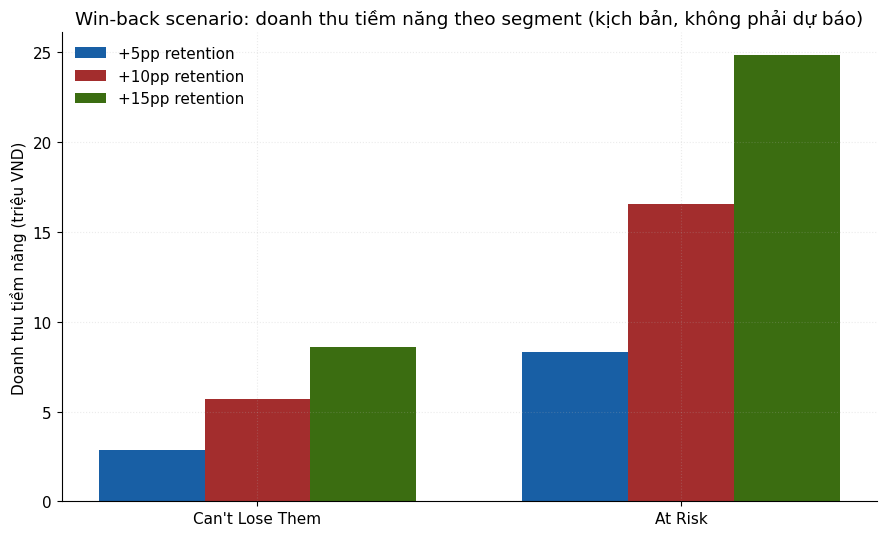

In [4]:
print("\n" + "=" * 70)
print("ĐỀ XUẤT 2 — WIN-BACK THEO RFM SEGMENT")
print("=" * 70)

rfm = pd.read_csv(P3 / "rfm_customer_segments.csv")
churn = pd.read_csv(P3 / "churn_risk_scores.csv")

target_segments = ["Can't Lose Them", "At Risk"]
uplift_scenarios = [0.05, 0.10, 0.15]  # X điểm % tăng tỷ lệ giữ chân (kịch bản, KHÔNG phải dự báo)

rows = []
for seg in target_segments:
    sub = rfm[rfm["segment"] == seg]
    n_cust = len(sub)
    total_monetary = sub["monetary"].sum()
    total_frequency = sub["frequency"].sum()
    avg_monetary = sub["monetary"].mean()
    aov = total_monetary / total_frequency  # giá trị trung bình 1 đơn hàng lịch sử của khách trong segment
    for x in uplift_scenarios:
        n_retained = n_cust * x
        revenue_potential = n_retained * aov
        rows.append({
            "segment": seg, "n_customers": n_cust,
            "avg_monetary_vnd": avg_monetary, "avg_order_value_vnd": aov,
            "uplift_scenario_pct": x * 100,
            "n_customers_retained_est": n_retained,
            "revenue_potential_vnd": revenue_potential,
        })
    print(f"\nSegment: {seg}")
    print(f"  Số khách: {n_cust:,} | Monetary TB/khách: {avg_monetary:,.0f} VND | AOV TB: {aov:,.0f} VND")
    for x in uplift_scenarios:
        n_retained = n_cust * x
        revenue_potential = n_retained * aov
        print(f"  Kịch bản +{x*100:.0f}pp retention -> ~{n_retained:.0f} khách quay lại "
              f"-> +{revenue_potential/1e6:,.1f} triệu VND (1 đơn/khách)")

winback = pd.DataFrame(rows)
winback.to_csv(OUT_DATA / "winback_scenario_by_segment.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
width = 0.25
x_pos = np.arange(len(target_segments))
for i, x in enumerate(uplift_scenarios):
    vals = [winback[(winback.segment == s) & (winback.uplift_scenario_pct == x*100)]["revenue_potential_vnd"].values[0] / 1e6
            for s in target_segments]
    ax.bar(x_pos + i*width, vals, width=width, label=f"+{x*100:.0f}pp retention", color=PALETTE[i])
ax.set_xticks(x_pos + width)
ax.set_xticklabels(target_segments)
ax.set_ylabel("Doanh thu tiềm năng (triệu VND)")
ax.set_title("Win-back scenario: doanh thu tiềm năng theo segment (kịch bản, không phải dự báo)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_CHART / "37_winback_revenue_scenario.png", dpi=110)
plt.show()
plt.close(fig)

**Phân tích chart 37 — Win-back revenue scenario theo RFM segment**

1. **Thể hiện gì:** doanh thu tiềm năng theo kịch bản retention +5/+10/+15 điểm % cho 2 segment (Can't Lose Them, At Risk).
2. **Insight:** Can't Lose Them (2,251 khách, Monetary/khách 218,601 VND) mang lại +2.9 đến +8.6 triệu VND tuỳ kịch bản; At Risk (7,989 khách, Monetary/khách 80,882 VND, quy mô lớn hơn 3.5 lần) mang lại +8.3 đến +24.9 triệu VND — tổng tiềm năng lớn hơn dù giá trị/khách thấp hơn.
3. **Lưu ý:** đây là ƯỚC TÍNH KỊCH BẢN (scenario), không phải dự báo — tỷ lệ +5/10/15pp là giả định minh hoạ, KHÔNG lấy từ A/B test thật; công thức chỉ tính 1 đơn quay lại/khách (bảo thủ) và CHƯA trừ chi phí campaign (voucher, nhân sự) — đây là doanh thu tiềm năng GỘP, chưa phải ROI ròng.


## ĐỀ XUẤT 3 — Nhân rộng pricing practice của West sang Central/East


ĐỀ XUẤT 3 — NHÂN RỘNG PRICING PRACTICE CỦA WEST
Tổng revenue (Central+East+West, theo category_region_margin_controlled): 15.689 tỷ VND
Margin toàn shop hiện tại: 13.47%

Giả định: Central/East đạt 60% khoảng cách margin so với West trong CÙNG category
 region   category  margin_pct  west_margin_pct    gap_pp  target_margin_pct  margin_gain_vnd
Central     Casual   11.590096        11.783742  0.193646          11.706284           0.0001
Central       GenZ   19.945001        18.279443 -1.665558          19.945001           0.0000
Central    Outdoor   15.716145        16.744078  1.027933          16.332905           0.0034
Central Streetwear   12.666209        13.277068  0.610859          13.032724           0.0146
   East     Casual   11.313971        11.783742  0.469771          11.595834           0.0005
   East       GenZ   18.830489        18.279443 -0.551046          18.830489           0.0000
   East    Outdoor   15.370812        16.744078  1.373266          16.194771           0

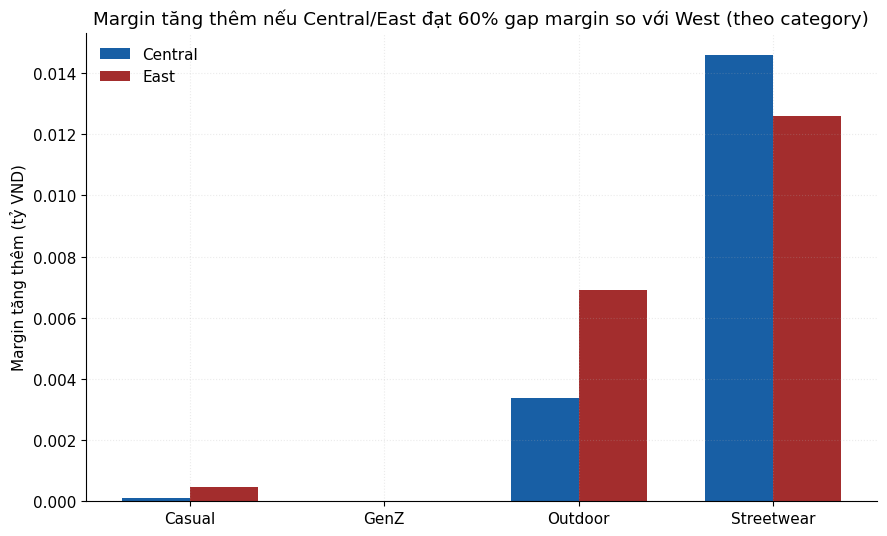

In [5]:
print("\n" + "=" * 70)
print("ĐỀ XUẤT 3 — NHÂN RỘNG PRICING PRACTICE CỦA WEST")
print("=" * 70)

crm = pd.read_csv(P2 / "category_region_margin_controlled.csv")
PRICE_EFFECT_SHARE = 0.60  # ~60% chênh lệch margin West là do giá thật tốt hơn (Phase 2 mục 2.3)

west = crm[crm.region == "West"].set_index("category")["margin_pct"]

rows3 = []
for reg in ["Central", "East"]:
    sub = crm[crm.region == reg].copy()
    sub["west_margin_pct"] = sub["category"].map(west)
    sub["gap_pp"] = sub["west_margin_pct"] - sub["margin_pct"]
    sub["gap_pp_positive"] = sub["gap_pp"].clip(lower=0)  # chỉ tính khi West thực sự tốt hơn
    sub["target_margin_pct"] = sub["margin_pct"] + PRICE_EFFECT_SHARE * sub["gap_pp_positive"]
    sub["cogs_new"] = sub["revenue"] * (1 - sub["target_margin_pct"] / 100)
    sub["margin_gain_vnd"] = sub["cogs"] - sub["cogs_new"]
    rows3.append(sub)

west_repl = pd.concat(rows3, ignore_index=True)
west_repl.to_csv(OUT_DATA / "west_margin_replication_by_category_region.csv", index=False)

total_gain = west_repl["margin_gain_vnd"].sum()
total_revenue_all = crm["revenue"].sum()
total_cogs_all = crm["cogs"].sum()
margin_pct_before = (1 - total_cogs_all / total_revenue_all) * 100
total_cogs_after = total_cogs_all - total_gain
margin_pct_after = (1 - total_cogs_after / total_revenue_all) * 100

print(f"Tổng revenue (Central+East+West, theo category_region_margin_controlled): {total_revenue_all/1e9:.3f} tỷ VND")
print(f"Margin toàn shop hiện tại: {margin_pct_before:.2f}%")
print(f"\nGiả định: Central/East đạt {PRICE_EFFECT_SHARE*100:.0f}% khoảng cách margin so với West trong CÙNG category")
print(west_repl[["region", "category", "margin_pct", "west_margin_pct", "gap_pp", "target_margin_pct", "margin_gain_vnd"]]
      .assign(margin_gain_vnd=lambda d: (d["margin_gain_vnd"]/1e9).round(4)).to_string(index=False))
print(f"\n=> Tổng margin tăng thêm: +{total_gain/1e9:.3f} tỷ VND")
print(f"=> Margin toàn shop mới: {margin_pct_after:.2f}% (+{margin_pct_after-margin_pct_before:.2f} điểm %)")

summary3 = pd.DataFrame([{
    "total_revenue_vnd": total_revenue_all, "margin_pct_before": margin_pct_before,
    "margin_pct_after": margin_pct_after, "margin_gain_pp": margin_pct_after - margin_pct_before,
    "margin_gain_vnd": total_gain, "price_effect_share_assumed": PRICE_EFFECT_SHARE,
}])
summary3.to_csv(OUT_DATA / "west_margin_replication_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5.5))
cats = west_repl["category"].unique()
x_pos = np.arange(len(cats))
width = 0.35
for i, reg in enumerate(["Central", "East"]):
    vals = [west_repl[(west_repl.category == c) & (west_repl.region == reg)]["margin_gain_vnd"].values[0] / 1e9
            for c in cats]
    ax.bar(x_pos + i*width, vals, width=width, label=reg, color=PALETTE[i])
ax.set_xticks(x_pos + width/2)
ax.set_xticklabels(cats)
ax.set_ylabel("Margin tăng thêm (tỷ VND)")
ax.set_title(f"Margin tăng thêm nếu Central/East đạt {PRICE_EFFECT_SHARE*100:.0f}% gap margin so với West (theo category)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_CHART / "38_west_margin_replication_uplift.png", dpi=110)
plt.show()
plt.close(fig)

**Phân tích chart 38 — Uplift nếu nhân rộng pricing practice của West**

1. **Thể hiện gì:** margin tăng thêm nếu Central/East áp dụng "pricing practice của West" (giả định nhân rộng 60% gap margin theo category).
2. **Insight:** tổng margin tăng thêm **+0.038 tỷ VND (38 triệu)** trên 10 năm, margin toàn shop 13.47%→13.71% (+0.24 điểm %); phần lớn đến từ Streetwear (Central +14.6 triệu, East +12.6 triệu) do chiếm tỷ trọng doanh thu lớn nhất.
3. **Lưu ý:** hệ số 60% lấy từ Phase 2 là ước lượng ở CẤP VÙNG (mix-adjustment toàn vùng), áp lại cho TỪNG category là đơn giản hoá, có thể không chính xác 100% (GenZ ở Central/East margin đã CAO HƠN West nên đã chặn gap ở 0, tránh kết quả âm vô lý); con số tuyệt đối rất nhỏ (~3.8 triệu/năm) — giá trị chính là ĐỊNH HƯỚNG vận hành pricing, không phải đòn bẩy tài chính lớn.


## Hoàn tất

In [6]:
print("\nHoàn tất Phase 4. CSV: phase4_prescriptive/data/*.csv | Chart: output/phase4/36-38_*.png")



Hoàn tất Phase 4. CSV: phase4_prescriptive/data/*.csv | Chart: output/phase4/36-38_*.png
